### Obtain

In [254]:
# polars
# fastexcel
# numpy
# seaborn
# matplotib
# scikit-learn
# pandas
# pyarrow

In [255]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

In [256]:
df_roturas = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="ROTURAS_RED_PRIMARIA",
)
df_fugas = pl.read_excel(
    "datasets/02_ROTURAS_RED_PRIMARIA_SECUNDARIA_PIURA.xlsx",
    sheet_name="FUGAS_RED_SECUNDARIA",
)
df_redes = pl.read_excel("datasets/03_REDES_CONEXIONES_PIURA.xlsx")
df_cau = pl.read_excel("datasets/01_BASE_CAUDALES_SECTORES_PIURA.xlsx")

## Reto 1

###  Inconsistencias geográficas

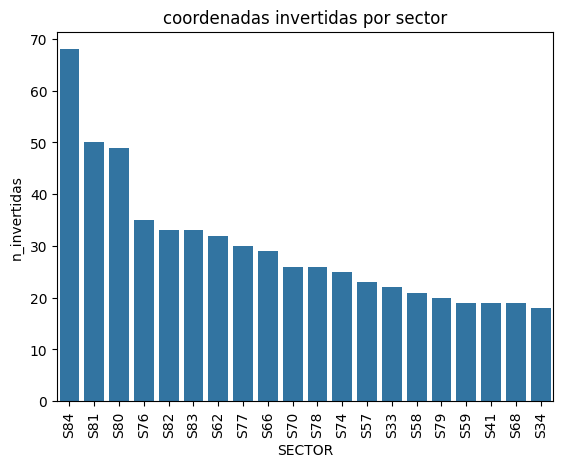

In [257]:
# conteo
inv_prim = (
    df_roturas.filter(pl.col("latitud") < -20)
    .group_by("SECTOR")
    .agg(pl.len().alias("n_invertidas"))
    .with_columns(pl.lit("roturas").alias("tipo"))
)
inv_sec = (
    df_fugas.filter(pl.col("latitud") < -20)
    .group_by("SECTOR")
    .agg(pl.len().alias("n_invertidas"))
    .with_columns(pl.lit("fugas").alias("tipo"))
)
df_coord_inv = pl.concat([inv_prim, inv_sec]).sort("n_invertidas", descending=True)

# grafico
sns.barplot(data=df_coord_inv.head(20).to_pandas(), x="SECTOR", y="n_invertidas")
plt.title("coordenadas invertidas por sector")
plt.xticks(rotation=90)
plt.show()

In [258]:
# correccion
df_roturas = (
    df_roturas.with_columns(
        [
            pl.when(pl.col("latitud") < -20)
            .then(pl.col("longitud"))
            .otherwise(pl.col("latitud"))
            .alias("lat_new"),
            pl.when(pl.col("latitud") < -20)
            .then(pl.col("latitud"))
            .otherwise(pl.col("longitud"))
            .alias("lon_new"),
        ]
    )
    .drop(["latitud", "longitud"])
    .rename({"lat_new": "latitud", "lon_new": "longitud"})
)

df_fugas = (
    df_fugas.with_columns(
        [
            pl.when(pl.col("latitud") < -20)
            .then(pl.col("longitud"))
            .otherwise(pl.col("latitud"))
            .alias("lat_new"),
            pl.when(pl.col("latitud") < -20)
            .then(pl.col("latitud"))
            .otherwise(pl.col("longitud"))
            .alias("lon_new"),
        ]
    )
    .drop(["latitud", "longitud"])
    .rename({"lat_new": "latitud", "lon_new": "longitud"})
)

print(df_roturas)
print(df_fugas)

shape: (726, 12)
┌──────────┬────────┬───────────────┬─────┬───┬────────────┬──────────────┬───────────┬────────────┐
│ CONEXION ┆ SECTOR ┆ CDESTIPSER    ┆ MES ┆ … ┆ fecha_fin  ┆ hora_fin     ┆ latitud   ┆ longitud   │
│ ---      ┆ ---    ┆ ---           ┆ --- ┆   ┆ ---        ┆ ---          ┆ ---       ┆ ---        │
│ i64      ┆ str    ┆ str           ┆ i64 ┆   ┆ date       ┆ datetime[ms] ┆ f64       ┆ f64        │
╞══════════╪════════╪═══════════════╪═════╪═══╪════════════╪══════════════╪═══════════╪════════════╡
│ 15       ┆ S74    ┆ AG:           ┆ 7   ┆ … ┆ 2025-07-14 ┆ 1899-12-31   ┆ -5.222965 ┆ -80.627582 │
│          ┆        ┆ Conexiones    ┆     ┆   ┆            ┆ 09:59:24.144 ┆           ┆            │
│          ┆        ┆ Domiciliarias ┆     ┆   ┆            ┆              ┆           ┆            │
│          ┆        ┆ …             ┆     ┆   ┆            ┆              ┆           ┆            │
│ 17       ┆ S74    ┆ AG:           ┆ 6   ┆ … ┆ 2025-06-04 ┆ 1899-12-31   

### Sobreregistro de datos

In [259]:
df_roturas = df_roturas.unique(subset=["CONEXION", "CATEGORIA", "fecha_inicio"])
df_fugas = df_fugas.unique(subset=["CONEXION", "CATEGORIA", "fecha_inicio"])

# tabla observaciones unicas
obs_unicas = pl.DataFrame(
    {"tipo": ["roturas", "fugas"], "conteo_unico": [df_roturas.height, df_fugas.height]}
)

print(obs_unicas)

shape: (2, 2)
┌─────────┬──────────────┐
│ tipo    ┆ conteo_unico │
│ ---     ┆ ---          │
│ str     ┆ i64          │
╞═════════╪══════════════╡
│ roturas ┆ 722          │
│ fugas   ┆ 10860        │
└─────────┴──────────────┘


## Reto 2: Consolidación de información a nivel de sector

### Ranking de roturas y fugas por sector

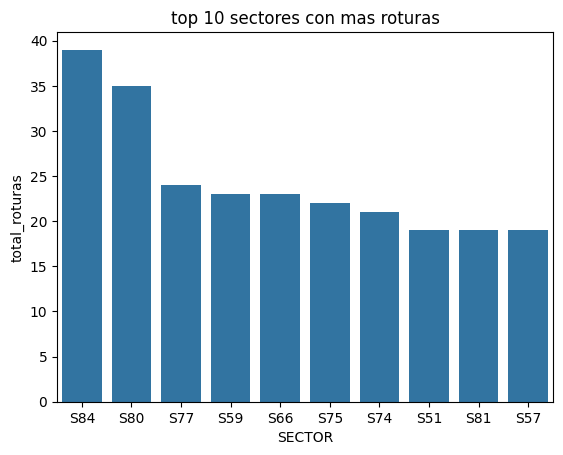

In [260]:
rank_rot = (
    df_roturas.group_by("SECTOR")
    .agg(pl.len().alias("total_roturas"))
    .sort("total_roturas", descending=True)
)
rank_fug = (
    df_fugas.group_by("SECTOR")
    .agg(pl.len().alias("total_fugas"))
    .sort("total_fugas", descending=True)
)

# grafico
sns.barplot(data=rank_rot.head(10).to_pandas(), x="SECTOR", y="total_roturas")
plt.title("top 10 sectores con mas roturas")
plt.show()

### Cálculo del tiempo de reparación

In [261]:
# roturas
df_rot_t = (
    df_roturas.with_columns(
        [
            pl.col("hora_inicio").dt.time().alias("h_i"),
            pl.col("hora_fin").dt.time().alias("h_f"),
        ]
    )
    .with_columns(
        [
            (pl.col("fecha_inicio").dt.combine(pl.col("h_i"))).alias("t1"),
            (pl.col("fecha_fin").dt.combine(pl.col("h_f"))).alias("t2"),
        ]
    )
    .with_columns(
        ((pl.col("t2") - pl.col("t1")).dt.total_seconds() / 3600).alias("horas")
    )
    .drop_nulls("horas")
)

prom_rot_sector = df_rot_t.group_by("SECTOR").agg(
    pl.col("horas").mean().alias("promedio_horas")
)
total_prom_rot = pl.DataFrame(
    {"SECTOR": ["TOTAL"], "promedio_horas": [df_rot_t["horas"].mean()]}
)
prom_rot_final = pl.concat([prom_rot_sector, total_prom_rot])

print(prom_rot_final)

shape: (74, 2)
┌────────┬────────────────┐
│ SECTOR ┆ promedio_horas │
│ ---    ┆ ---            │
│ str    ┆ f64            │
╞════════╪════════════════╡
│ S8     ┆ 50.807593      │
│ S59    ┆ 56.281111      │
│ S60    ┆ 61.807917      │
│ S73    ┆ 57.472569      │
│ S69    ┆ 66.65838       │
│ …      ┆ …              │
│ S57    ┆ 60.746184      │
│ S65    ┆ 70.134948      │
│ S6     ┆ 38.496944      │
│ S33    ┆ 68.859097      │
│ TOTAL  ┆ 61.195132      │
└────────┴────────────────┘


In [262]:
# fugas
df_fug_t = (
    df_fugas.with_columns(
        [
            pl.col("hora_inicio").dt.time().alias("h_i"),
            pl.col("hora_fin").dt.time().alias("h_f"),
        ]
    )
    .with_columns(
        [
            (pl.col("fecha_inicio").dt.combine(pl.col("h_i"))).alias("t1"),
            (pl.col("fecha_fin").dt.combine(pl.col("h_f"))).alias("t2"),
        ]
    )
    .with_columns(
        ((pl.col("t2") - pl.col("t1")).dt.total_seconds() / 3600).alias("horas")
    )
    .drop_nulls("horas")
)

prom_fug_sector = df_fug_t.group_by("SECTOR").agg(
    pl.col("horas").mean().alias("promedio_horas")
)
total_prom_fug = pl.DataFrame(
    {"SECTOR": ["TOTAL"], "promedio_horas": [df_fug_t["horas"].mean()]}
)
prom_fug_final = pl.concat([prom_fug_sector, total_prom_fug])

print(prom_fug_final)

shape: (83, 2)
┌────────┬────────────────┐
│ SECTOR ┆ promedio_horas │
│ ---    ┆ ---            │
│ str    ┆ f64            │
╞════════╪════════════════╡
│ S31    ┆ 26.188669      │
│ S69    ┆ 26.185451      │
│ S19    ┆ 25.993423      │
│ S34    ┆ 25.191294      │
│ S40    ┆ 27.016123      │
│ …      ┆ …              │
│ S56    ┆ 25.215943      │
│ S12    ┆ 24.25304       │
│ S36    ┆ 24.817492      │
│ S70    ┆ 26.773144      │
│ TOTAL  ┆ 25.965427      │
└────────┴────────────────┘


### Normalización de casos

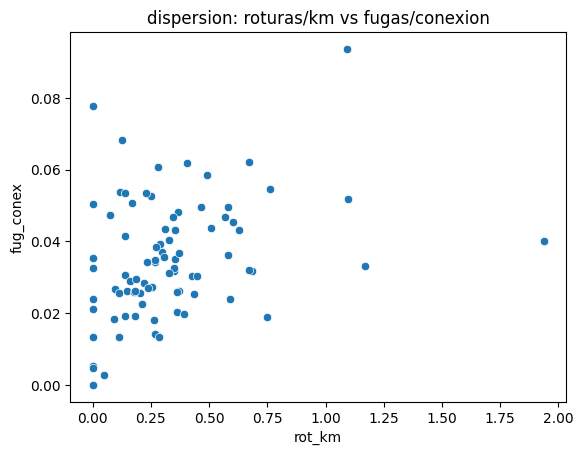

In [263]:
df_redes = df_redes.rename({"Conexiones": "conex", "red_distribucion": "m_dist"})
df_merged = (
    df_redes.join(rank_rot, on="SECTOR", how="left")
    .join(rank_fug, on="SECTOR", how="left")
    .fill_null(0)
)

df_merged = df_merged.with_columns(
    [
        (pl.col("total_roturas") / (pl.col("m_dist") / 1000)).alias("rot_km"),
        (pl.col("total_fugas") / pl.col("conex")).alias("fug_conex"),
    ]
)

# unimos con caudal promedio
df_clasif = df_merged.join(
    df_cau.select(["SECTOR", "PROMEDIO"]), on="SECTOR", how="left"
).rename({"PROMEDIO": "caudal_prom"})

sns.scatterplot(data=df_clasif.to_pandas(), x="rot_km", y="fug_conex")
plt.title("dispersion: roturas/km vs fugas/conexion")
plt.show()

### Análisis de agrupamiento

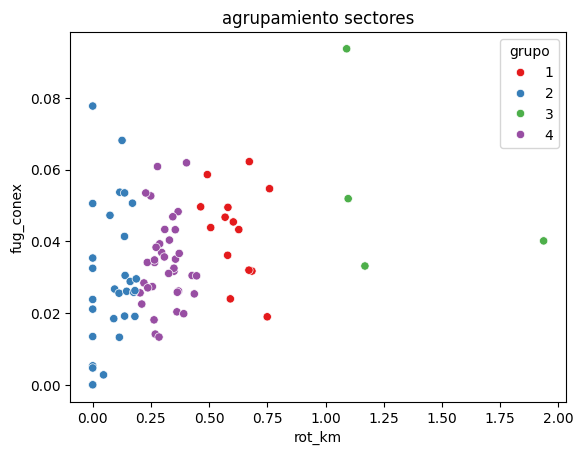

In [264]:
km = KMeans(n_clusters=4, random_state=42)
coords_cluster = df_clasif.select(["rot_km", "fug_conex"]).to_numpy()
df_clasif = df_clasif.with_columns(
    pl.Series("grupo", km.fit_predict(coords_cluster) + 1)
)

# grafico
sns.scatterplot(
    data=df_clasif.to_pandas(), x="rot_km", y="fug_conex", hue="grupo", palette="Set1"
)
plt.title("agrupamiento sectores")
plt.show()

## Reto 3: Calculo de la senda optima de reparaciones

In [ ]:
# filtrar dia especifico
dia = "2025-03-28"
puntos_dia = df_roturas.filter(pl.col("fecha_inicio") == dia.dt).select(["CONEXION", "latitud", "longitud"]).unique()

# sede piura
lat_eps, lon_eps = -5.190628, -80.641601
puntos_lista = [{"id": "PARTIDA", "lat": lat_eps, "lon": lon_eps}]
for r in puntos_dia.to_dicts():
    puntos_lista.append({"id": str(r["CONEXION"]), "lat": r["latitud"], "lon": r["longitud"]})

# logica del vecino mas cercano (greedy)
recorrido = [puntos_lista[0]]
restantes = puntos_lista[1:]

while restantes:
    actual = recorrido[-1]
    # encontrar el mas cercano usando formula euclidiana simple
    siguiente = min(restantes, key=lambda p: math.sqrt((p["lat"]-actual["lat"])**2 + (p["lon"]-actual["lon"])**2))
    recorrido.append(siguiente)
    restantes.remove(siguiente)

recorrido.append(puntos_lista[0]) # volver a sede

# grafico de la ruta
df_ruta_plot = pd.DataFrame(recorrido)
plt.plot(df_ruta_plot["lon"], df_ruta_plot["lat"], "bo-")
plt.plot(lon_eps, lat_eps, "rs", markersize=10, label="sede")
plt.title("senda optima de reparaciones - 28/03/2025")
plt.legend()
plt.show()

InvalidOperationError: cannot compare 'date/datetime/time' to a string value (create native python { 'date', 'datetime', 'time' } or compare to a temporal column)